In [3]:
%load_ext autoreload
%autoreload 2

%matplotlib inline

import os
from os.path import join
import json
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
mpl.style.use('../../style.mcstyle')   # noqa
import numpy as np
import torch
import seaborn as sns
import pandas as pd
import warnings
from tqdm import tqdm

# from tools import torch_device

# device = torch_device()

# Suppress warnings
warnings.filterwarnings('ignore')

Duplicate key in file '../../style.mcstyle', line 16 ('font.family: serif')


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
filename = '/anvil/scratch/x-mho1/cmass-ili/mtnglike/fastpm_recnoise/models/ngc_lightcone/nbar+Pk0/kmin-0.0_kmax-0.4/x_test.npy'
xsim = np.load(filename)
filename = '/anvil/scratch/x-mho1/cmass-ili/mtnglike/fastpm_recnoise/models/ngc_lightcone/nbar+Pk0/kmin-0.0_kmax-0.4/theta_test.npy'
tsim = np.load(filename)

In [25]:
filename = '/anvil/scratch/x-mho1/cmass-ili/quijote3gpch/nbody_4noise/models/ngc_lightcone/nbar+Pk0/kmin-0.0_kmax-0.4/x_test.npy'
xobs = np.load(filename)

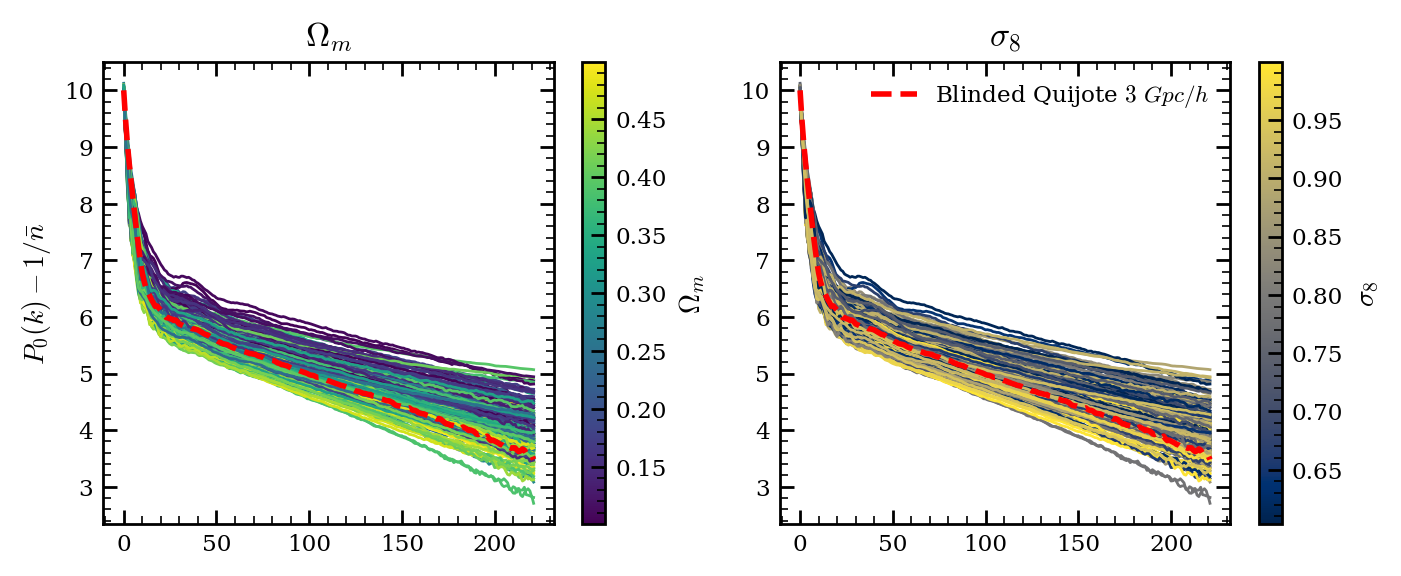

In [ ]:
f, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3), sharex=True)

# First subplot for Omega_m
norm1 = mcolors.Normalize(vmin=tsim[:, 0].min(), vmax=tsim[:, 0].max())
scaler1 = plt.cm.ScalarMappable(norm=norm1, cmap='viridis')

ss = 10  # Subsampling factor
for i, x in enumerate(xsim[::ss]):
    ax1.plot(x[:-10], color=scaler1.to_rgba(tsim[i * ss, 0]), lw=1)
scaler1.set_array([])
ax1.set_ylabel(r'$P_0(k) - 1/\bar{n}$')
ax1.set_title(r'$\Omega_m$')
ax1.plot(xobs[0, :-10], 'r--', label=r'Blinded Quijote $3\ Gpc/h$')
f.colorbar(scaler1, ax=ax1, label=r'$\Omega_m$')

# Second subplot for sigma8
norm2 = mcolors.Normalize(vmin=tsim[:, 4].min(), vmax=tsim[:, 4].max())
scaler2 = plt.cm.ScalarMappable(norm=norm2, cmap='cividis')

for i, x in enumerate(xsim[::ss]):
    ax2.plot(x[:-10], color=scaler2.to_rgba(tsim[i * ss, 4]), lw=1)
scaler2.set_array([])
# ax2.set_ylabel(r'$P_0(k) - 1/\bar{n}$')
ax2.set_title(r'$\sigma_8$')
ax2.plot(xobs[0, :-10], 'r--', label=r'Blinded Quijote $3\ Gpc/h$')
f.colorbar(scaler2, ax=ax2, label=r'$\sigma_8$')
ax2.legend(loc='upper right')

In [ ]:
xobs[:, :-10]

array([[10.00320166,  9.48591447,  9.05497492, ...,  3.55138567,
         3.55520817,  3.48111651],
       [ 9.9421285 ,  9.33026781,  8.75759157, ...,  3.13271408,
         3.09995058,  3.1183396 ],
       [ 9.89766774,  9.23120385,  8.6653227 , ...,  3.67227714,
         3.62206779,  3.59576934],
       ...,
       [ 9.98203297,  9.33338855,  8.61609499, ...,  3.42396198,
         3.37571302,  3.40081292],
       [10.04731868,  9.46989029,  8.90641756, ...,  3.70684276,
         3.67259176,  3.67090001],
       [ 9.96479115,  9.38042163,  8.84115862, ...,  3.17583105,
         3.1954365 ,  3.17921796]])